In [1]:
import wandb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

api = wandb.Api()

entity = "alu-lilit"  # your username or team
project = "thesis"  # your project name

# Get all runs from the project
runs = api.runs(f"{entity}/{project}")

# Filter runs by name/tags
filtering_runs = [r for r in runs if "filtering" in r.name.lower()]
raml_runs = [r for r in runs if "raml_final" in r.name.lower()]

print(f"Found {len(filtering_runs)} filtering runs")
print(f"Found {len(raml_runs)} RAML runs")


Found 1 filtering runs
Found 3 RAML runs


In [2]:
def get_metrics_from_run(run, metric_names):
    """Extract specific metrics from a W&B run"""
    history = run.history()
    
    data = {}
    for metric in metric_names:
        if metric in history.columns:
            data[metric] = history[metric].values
        else:
            print(f"Warning: {metric} not found in run {run.name}")
    
    return data

# Metrics to extract
loss_metrics = [
    'Validation on train loss',      # or whatever you logged it as
    'Validation loss',
    'Epoch'
]

score_metrics = [
    'Train Score',     # mean ΔG on training subsample
    'Vaidation Score',       # mean ΔG on validation subsample
    'Epoch'
]

In [3]:
filtering_run = filtering_runs[0]  # assuming one filtering run
filtering_data = get_metrics_from_run(filtering_run, loss_metrics + score_metrics)

train_loss = filtering_data['Validation on train loss'][1:16]
val_loss = filtering_data['Validation loss'][1:16]
train_scores = filtering_data['Train Score'][1:16]
validation_scores = filtering_data['Vaidation Score'][1:16]

filtering_train_loss = train_loss - train_loss[0]
filtering_val_loss = val_loss - val_loss[0]
filtering_train_score = train_scores - train_scores[0]
filtering_val_score = validation_scores - validation_scores[0]
epochs = filtering_data['Epoch'][1:16]

print(f"Filtering epochs: {len(epochs)}")

Filtering epochs: 15


In [4]:
print("\n=== RAML Runs (3 seeds) ===")

raml_train_losses = []
raml_val_losses = []
raml_train_scores = []
raml_val_scores = []

for i, run in enumerate(raml_runs[:3]):  # take first 3 RAML runs
    print(f"Processing RAML seed {i+1}: {run.name}")
    
    data = get_metrics_from_run(run, loss_metrics + score_metrics)
    
    train_loss = data['Validation on train loss'][1:16]
    val_loss = data['Validation loss'][1:16]
    train_scores = data['Train Score'][1:16]
    validation_scores = data['Vaidation Score'][1:16]
    
    raml_train_losses.append(train_loss - train_loss[0])
    raml_val_losses.append(val_loss - val_loss[0])
    raml_train_scores.append(train_scores - train_scores[0])
    raml_val_scores.append(validation_scores - validation_scores[0])

# Convert to numpy arrays (shape: [3 seeds, 15 epochs])
raml_train_losses = np.array(raml_train_losses)
raml_val_losses = np.array(raml_val_losses)
raml_train_scores = np.array(raml_train_scores)
raml_val_scores = np.array(raml_val_scores)

print(f"RAML array shapes: {raml_train_losses.shape}")

raml_train_loss_mean = raml_train_losses.mean(axis=0)
raml_train_loss_std = raml_train_losses.std(axis=0)
raml_val_loss_mean = raml_val_losses.mean(axis=0)
raml_val_loss_std = raml_val_losses.std(axis=0)

raml_train_score_mean = raml_train_scores.mean(axis=0)
raml_train_score_std = raml_train_scores.std(axis=0)
raml_val_score_mean = raml_val_scores.mean(axis=0)
raml_val_score_std = raml_val_scores.std(axis=0)




=== RAML Runs (3 seeds) ===
Processing RAML seed 1: time_split_raml_final1_2026-02-11_14-28
Processing RAML seed 2: time_split_raml_final2_2026-02-11_22-07
Processing RAML seed 3: time_split_raml_final3_2026-02-12_15-08
RAML array shapes: (3, 15)


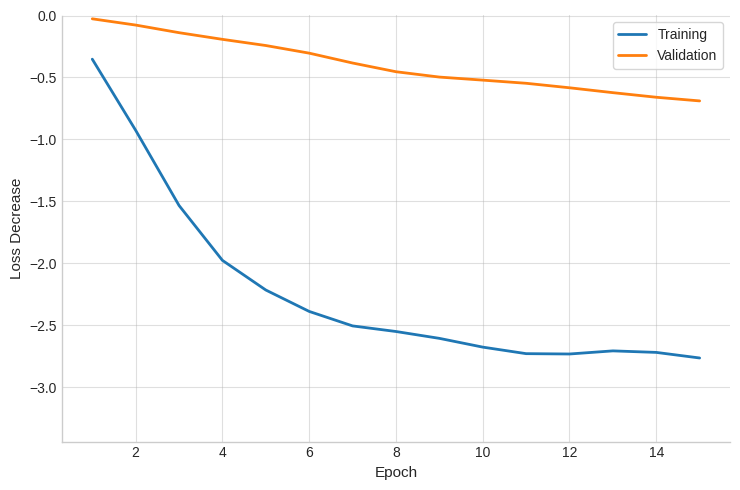

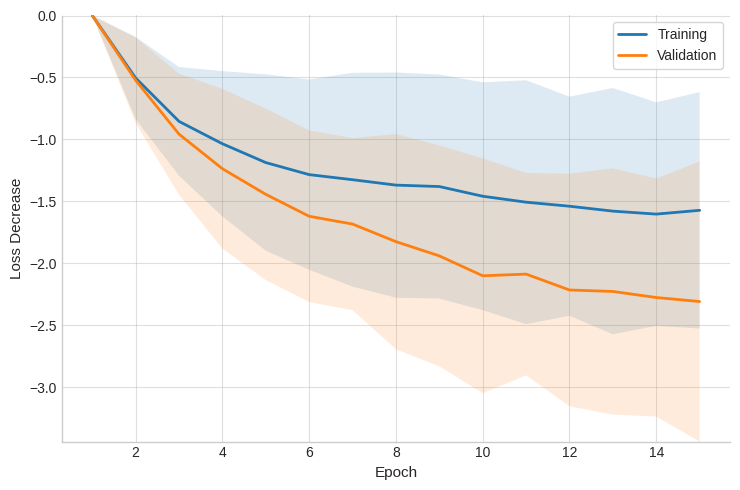

In [5]:
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

sigma = 1.0
filtering_train_loss_smooth = gaussian_filter1d(
    filtering_train_loss, sigma=sigma, mode='nearest'
)
filtering_val_loss_smooth = gaussian_filter1d(
    filtering_val_loss, sigma=sigma, mode='nearest'
)

# Shared y-limits
y_min = min(
    filtering_train_loss_smooth.min(),
    filtering_val_loss_smooth.min(),
    (raml_train_loss_mean - raml_train_loss_std).min(),
    (raml_val_loss_mean - raml_val_loss_std).min()
)

y_max = max(
    filtering_train_loss_smooth.max(),
    filtering_val_loss_smooth.max(),
    (raml_train_loss_mean + raml_train_loss_std).max(),
    (raml_val_loss_mean + raml_val_loss_std).max()
)

# ========================================
# FIGURE 1: Supervised Filtering
# ========================================
fig1, ax1 = plt.subplots(figsize=(7.5, 5))

ax1.grid(True, color='#B0B0B0', alpha=0.4, linewidth=0.8)
ax1.set_ylim(y_min, y_max)

ax1.plot(
    epochs,
    filtering_train_loss_smooth,
    label='Training',
    color='tab:blue',
    linewidth=2
)
ax1.plot(
    epochs,
    filtering_val_loss_smooth,
    label='Validation',
    color='tab:orange',
    linewidth=2
)

ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss Decrease', fontsize=11)
ax1.legend(frameon=True)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

plt.tight_layout()
fig1.savefig('figures/filtering_loss.pdf', bbox_inches='tight')
fig1.savefig('figures/filtering_loss.png', dpi=300, bbox_inches='tight')


# ========================================
# FIGURE 2: RAML (mean ± std)
# ========================================
fig2, ax2 = plt.subplots(figsize=(7.5, 5))

ax2.grid(True, color='#B0B0B0', alpha=0.4, linewidth=0.8)
ax2.set_ylim(y_min, y_max)

ax2.plot(
    epochs,
    raml_train_loss_mean,
    label='Training',
    color='tab:blue',
    linewidth=2
)
ax2.fill_between(
    epochs,
    raml_train_loss_mean - raml_train_loss_std,
    raml_train_loss_mean + raml_train_loss_std,
    alpha=0.15
)

ax2.plot(
    epochs,
    raml_val_loss_mean,
    label='Validation',
    color='tab:orange',
    linewidth=2
)
ax2.fill_between(
    epochs,
    raml_val_loss_mean - raml_val_loss_std,
    raml_val_loss_mean + raml_val_loss_std,
    alpha=0.15
)

ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Loss Decrease', fontsize=11)
ax2.legend(frameon=True)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
fig2.savefig('figures/raml_loss.pdf', bbox_inches='tight')
fig2.savefig('figures/raml_loss.png', dpi=300, bbox_inches='tight')

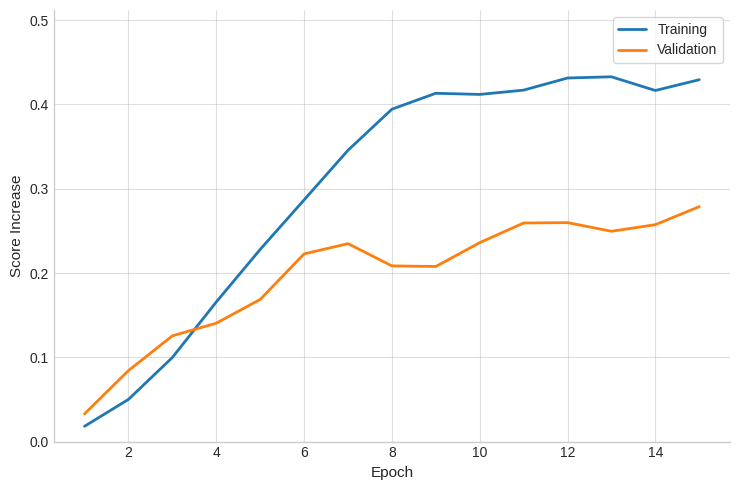

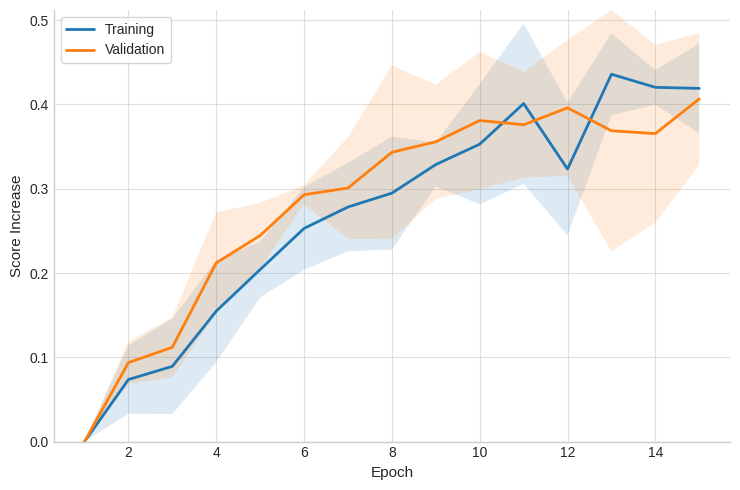

In [6]:
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

sigma = 1.0
filtering_train_score_smooth = gaussian_filter1d(
    filtering_train_score, sigma=sigma, mode='nearest'
)
filtering_val_score_smooth = gaussian_filter1d(
    filtering_val_score, sigma=sigma, mode='nearest'
)

# Shared y-limits
y_min = min(
    filtering_train_score_smooth.min(),
    filtering_val_score_smooth.min(),
    (raml_train_score_mean - raml_train_score_std).min(),
    (raml_val_score_mean - raml_val_score_std).min()
)

y_max = max(
    filtering_train_score_smooth.max(),
    filtering_val_score_smooth.max(),
    (raml_train_score_mean + raml_train_score_std).max(),
    (raml_val_score_mean + raml_val_score_std).max()
)

# ========================================
# FIGURE 1: Supervised Filtering (Scores)
# ========================================
fig1, ax1 = plt.subplots(figsize=(7.5, 5))

ax1.grid(True, color='#B0B0B0', alpha=0.4, linewidth=0.8)
ax1.set_ylim(y_min, y_max)

ax1.plot(
    epochs,
    filtering_train_score_smooth,
    label='Training',
    color='tab:blue',
    linewidth=2
)
ax1.plot(
    epochs,
    filtering_val_score_smooth,
    label='Validation',
    color='tab:orange',
    linewidth=2
)

ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Score Increase', fontsize=11)
ax1.legend(frameon=True)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

plt.tight_layout()
fig1.savefig('figures/filtering_scores.pdf', bbox_inches='tight')
fig1.savefig('figures/filtering_scores.png', dpi=300, bbox_inches='tight')


# ========================================
# FIGURE 2: RAML (Scores, mean ± std)
# ========================================
fig2, ax2 = plt.subplots(figsize=(7.5, 5))

ax2.grid(True, color='#B0B0B0', alpha=0.4, linewidth=0.8)
ax2.set_ylim(y_min, y_max)

ax2.plot(
    epochs,
    raml_train_score_mean,
    label='Training',
    color='tab:blue',
    linewidth=2
)
ax2.fill_between(
    epochs,
    raml_train_score_mean - raml_train_score_std,
    raml_train_score_mean + raml_train_score_std,
    alpha=0.15
)

ax2.plot(
    epochs,
    raml_val_score_mean,
    label='Validation',
    color='tab:orange',
    linewidth=2
)
ax2.fill_between(
    epochs,
    raml_val_score_mean - raml_val_score_std,
    raml_val_score_mean + raml_val_score_std,
    alpha=0.15
)

ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Score Increase', fontsize=11)
ax2.legend(frameon=True)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
fig2.savefig('figures/raml_scores.pdf', bbox_inches='tight')
fig2.savefig('figures/raml_scores.png', dpi=300, bbox_inches='tight')